# Measured Gate Characteristics

Fetching from: https://raw.githubusercontent.com/CIDARLAB/Cello-UCF/develop/files/v2/ucf/Eco/Eco1C2G2T2.UCF.json
Loaded UCF data successfully — total entries: 459
Collections in this UCF: {'functions', 'header', 'measurement_std', 'structures', 'parts', 'motif_library', 'circuit_rules', 'genetic_locations', 'device_rules', 'gates', 'models', 'logic_constraints'}
{'author': ['Jonghyeon Shin', 'Shuyi Zhang', 'Timothy Jones'],
 'collection': 'header',
 'date': 'Mon Jun 17 14:13:20 EDT 2019',
 'description': 'TetR homologs: PhlF, SrpR, BM3R1, HlyIIR, BetI, AmtR, AmeR, '
                'QacR, IcaRA',
 'genome': 'NEB 10 ∆(ara-leu) 7697 araD139 fhuA ∆lacX74 galK16 galE15 e14- '
           'φ80dlacZ∆M15  recA1 relA1 endA1 nupG  rpsL (StrR) rph spoT1 '
           '∆(mrr-hsdRMS-mcrBC)',
 'growth': 'Inoculation: Individual colonies into M9 media, 16 hours overnight '
           'in plate shaker.  Dilution: Next day, cells dilute ~200-fold into '
           'M9 media with antibiotics, growth for 

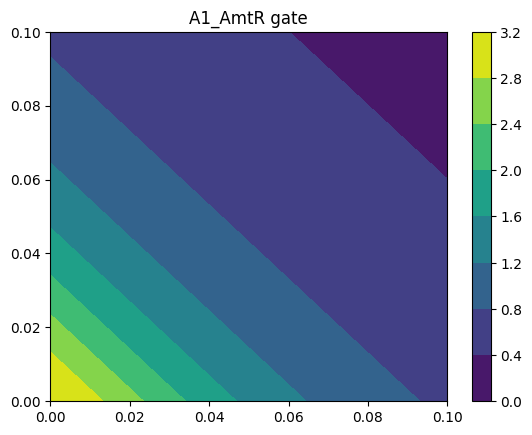

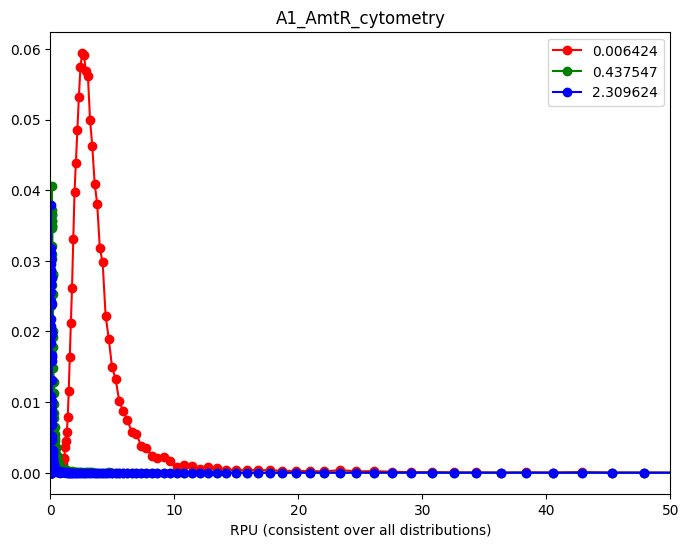

In [1]:
from urllib.request import urlopen
import json
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
%matplotlib inline
import ssl

ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode = ssl.CERT_NONE

def github_to_raw(url: str) -> str:
    if not url.startswith("https://github.com/"):
        raise ValueError("Not a valid GitHub URL")

    parts = url.replace("https://github.com/", "").split("/")
    if len(parts) < 5 or parts[2] != "blob":
        raise ValueError("URL must contain 'blob' and branch information")

    user, repo, _, branch = parts[:4]
    path = "/".join(parts[4:])
    return f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{path}"

url = "https://github.com/CIDARLAB/Cello-UCF/blob/develop/files/v2/ucf/Eco/Eco1C2G2T2.UCF.json"

raw_url = github_to_raw(url)
print("Fetching from:", raw_url)

with urlopen(raw_url, context=ssl_ctx) as resp:
    text = resp.read().decode("utf-8", errors="replace")

ucf_data = json.loads(text)
print("Loaded UCF data successfully — total entries:", len(ucf_data))

collections = set(entry.get("collection") for entry in ucf_data)
print("Collections in this UCF:", collections)

from pprint import pprint

pprint(ucf_data[0])


pprint(set([d['collection'] for d in ucf_data]))

gates_lib = [d for d in ucf_data if d['collection'] == 'gates']

gate_names = map(lambda x: x["name"], gates_lib[:100])
print(f"There are {len(gates_lib)} gates. in this library. Their names are:")
pprint(list(gate_names))

gate_name = 'A1_AmtR'

# uncomment to try another gate
# gate_name = 'S1_SrpR'

gate = [g for g in gates_lib if g['name'] == gate_name][0]
pprint(gate)

# check is all gates are NOR
all([g['gate_type'] == 'NOR' for g in gates_lib])

structure_lib = [d for d in ucf_data if d['collection'] == 'structures']
print(f"There are {len(structure_lib)} structures in the dataset.\n")

# find matching structure for the chosen gate
structure = [s for s in structure_lib if s['name'] == gate['structure']][0]
pprint(structure)

parts = ['BydvJ', 'A1', 'AmtR', 'L3S2P55']
parts_lib = [d for d in ucf_data if d['collection'] == 'parts' and d["name"] in parts]
pprint(parts_lib)

model_lib = [d for d in ucf_data if d['collection'] == 'models']
model = [m for m in model_lib if m['name'] == gate['model']][0]
pprint(model)

functions_lib = [d for d in ucf_data if d['collection'] == 'functions']

print('The first two elements describe these theoretical models:\n')
pprint(functions_lib[0])
print()
pprint(functions_lib[1])
print()
pprint(functions_lib[2])

params = {}
for p in model['parameters']:
    params[p['name']] = np.float64(p['value'])
    print(f"{p['name']}: {p['value']}")

def inv(x):
    return params['ymin'] + (params['ymax'] - params['ymin']) / (1.0 + (x / params['K'])**params['n'])

def nor(x, y):
    inputs = x + y  # linear input combination
    return inv(inputs)

def contour_fun(x, y, z, title=None):
    """
    Make a filled contour plot given x, y, z
    in 2D arrays.
    """
    plt.figure()
    CS = plt.contourf(x, y, z)
    cbar = plt.colorbar(CS)
    if title is not None:
        plt.title(title)

def contour_fun(x, y, z, title=None):
    """
    Make a filled contour plot given x, y, z
    in 2D arrays.
    """
    plt.figure()
    CS = plt.contourf(x, y, z)
    cbar = plt.colorbar(CS)
    if title is not None:
        plt.title(title)

# Get x and y values for plotting
x = np.linspace(0, 0.1, 200)
y = np.linspace(0, 0.1, 200)
xx, yy = np.meshgrid(x, y)

# plot it
contour_fun(
    xx, yy,
    nor(xx, yy),
    title=f"{gate_name} gate"
)

pprint([f["name"] for f in functions_lib])

gate_cytometry_name = f"{gate_name}_cytometry"
gate_cytometry = [f for f in functions_lib if f["name"] == gate_cytometry_name][0]

pprint(gate_cytometry)

name = gate_cytometry['name']
measurements = gate_cytometry['table']

plt.figure(figsize=(8, 6))
plt.title(name)
plt.xlabel('RPU (consistent over all distributions)')

# Show some distributions
d = measurements[0]
plt.plot(d['bin'], d['output'], 'ro-', label=d['x'])

middle = int( len(measurements) / 2 )
d = measurements[middle]
plt.plot(d['bin'], d['output'], 'go-', label=d['x'])

d = measurements[-1]
plt.plot(d['bin'], d['output'], 'bo-', label=d['x'])

ax = plt.gca()
ax.set_xlim(0, 50)
plt.legend()

print(f"Checking if distribution. This should be 1: {sum(d['output'])}")

### Model based on measurements

Found 18 NOR gates


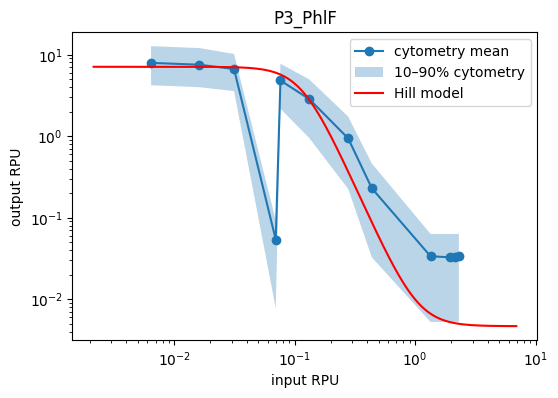

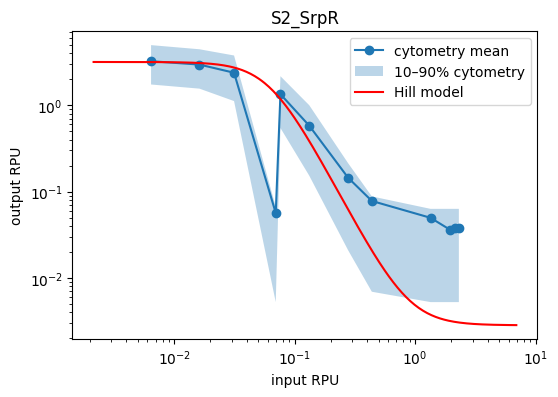

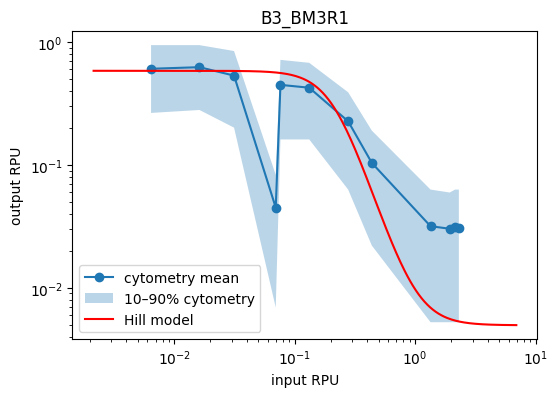

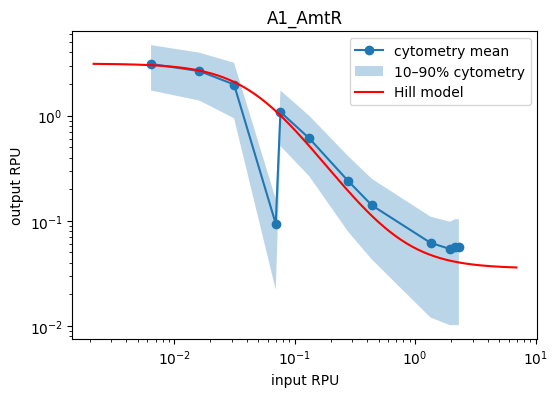

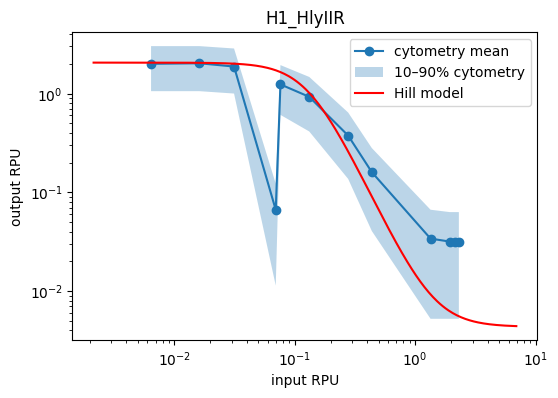

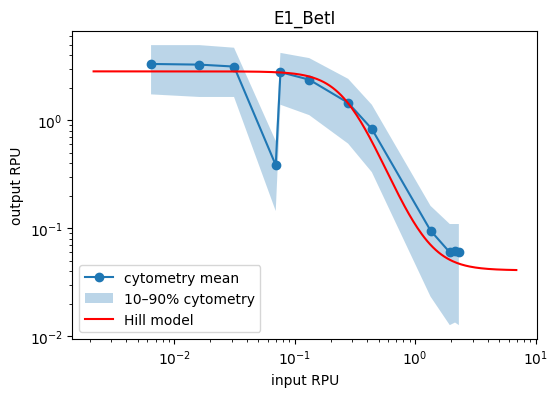

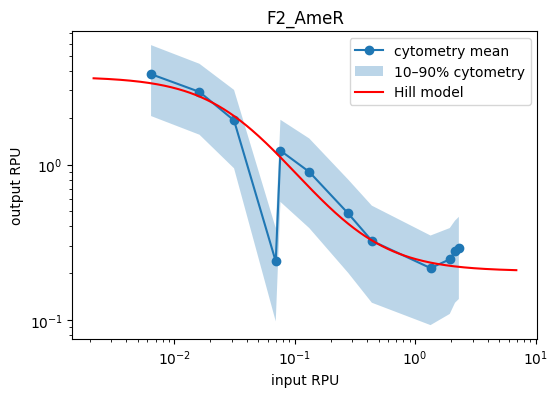

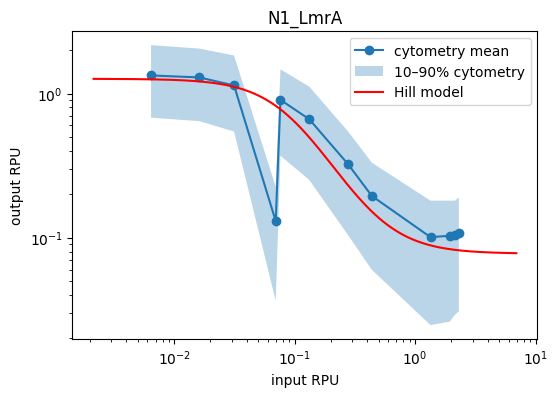

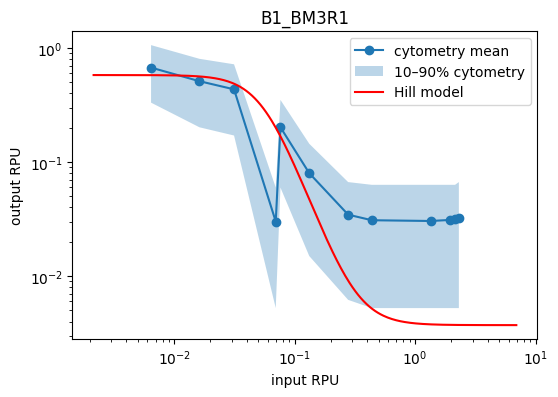

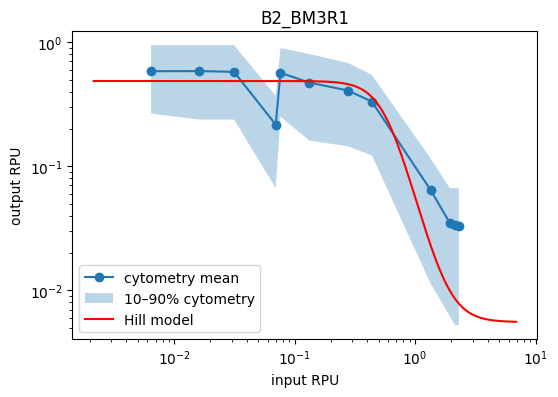

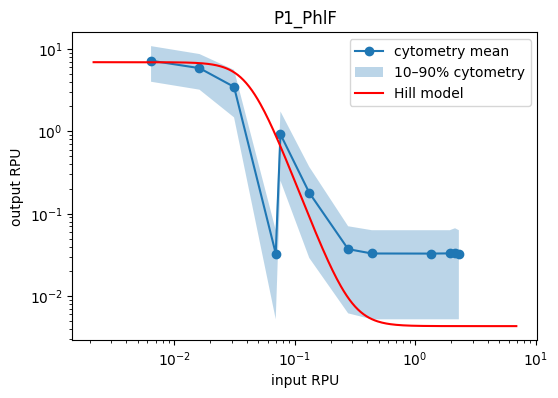

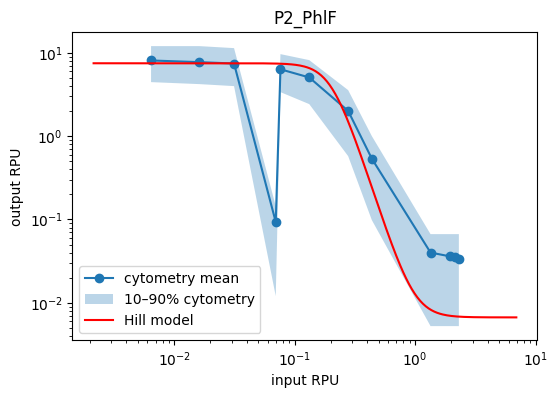

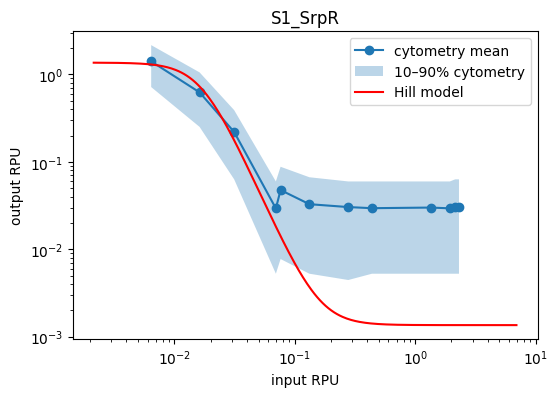

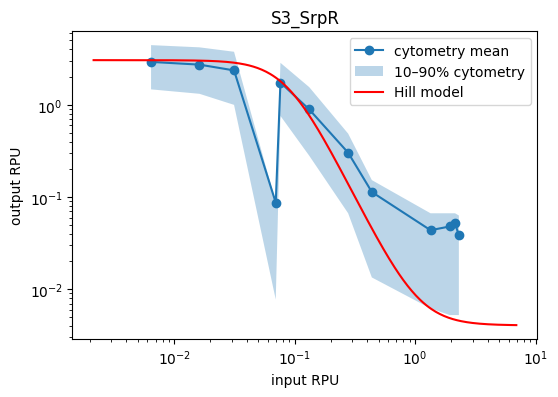

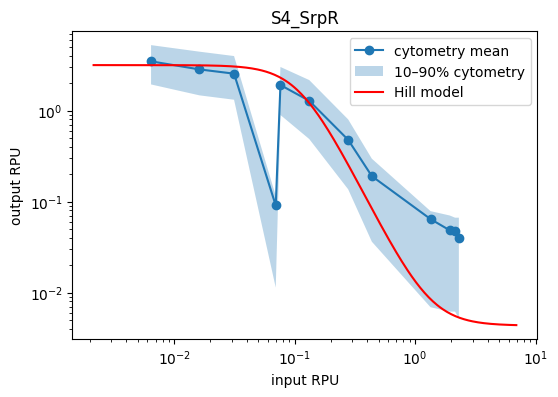

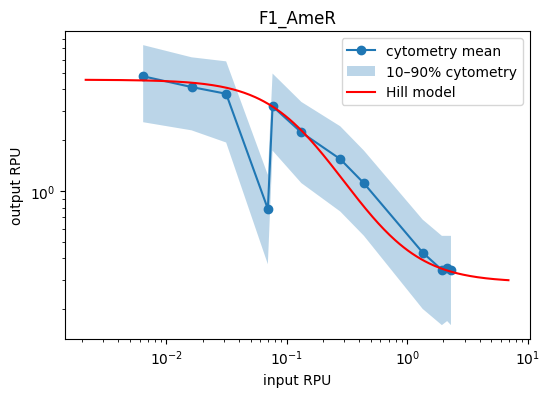

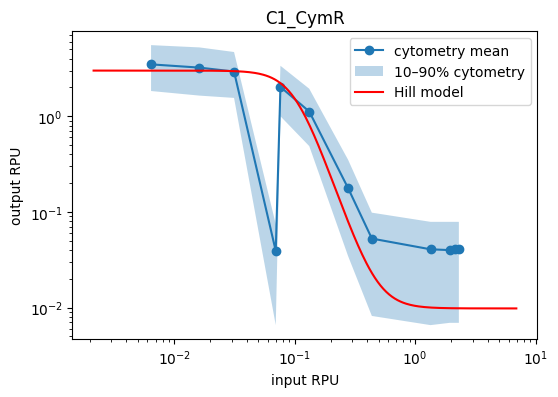

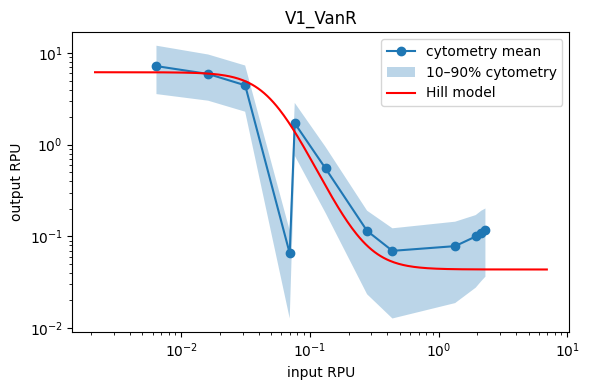

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rv_discrete

def make_inv_from_model(model_entry):
    params = {p['name']: float(p['value']) for p in model_entry['parameters']}
    ymin = params['ymin']
    ymax = params['ymax']
    K    = params['K']
    n    = params['n']
    def inv(x):
        return ymin + (ymax - ymin) / (1.0 + (x / K)**n)
    return inv

nor_gates = [g for g in gates_lib if g.get('gate_type') == 'NOR']
print(f"Found {len(nor_gates)} NOR gates")

model_by_name = {m['name']: m for m in model_lib}

func_by_name = {f['name']: f for f in functions_lib}

for gate in nor_gates:
    gate_name = gate['name']
    model_name = gate['model']

    model_entry = model_by_name[model_name]
    inv = make_inv_from_model(model_entry)

    cyt_name = f"{gate_name}_cytometry"
    if cyt_name not in func_by_name:
        print(f"[WARN] No cytometry for {gate_name}, plotting only deterministic Hill.")
        plt.figure(figsize=(5,4))
        x_plot = np.logspace(-3, 2, 400)
        plt.plot(x_plot, inv(x_plot), label='Hill model', color='red')
        plt.xscale('log')
        plt.yscale('log')
        plt.title(gate_name)
        plt.legend()
        continue

    gate_cytometry = func_by_name[cyt_name]
    measurements = gate_cytometry['table']

    x_vals = []
    means = []
    q10 = []
    q90 = []

    for d in measurements:
        x_input = float(d['x'])
        vals = np.array(d['bin'], dtype=float)
        probs = np.array(d['output'], dtype=float)

        probs = probs / probs.sum()

        dist = rv_discrete(values=(vals, probs))
        mean = dist.mean()
        q10_val = dist.ppf(0.1)
        q90_val = dist.ppf(0.9)

        x_vals.append(x_input)
        means.append(mean)
        q10.append(q10_val)
        q90.append(q90_val)

    x_vals = np.array(x_vals)
    means = np.array(means)
    q10 = np.array(q10)
    q90 = np.array(q90)

    sort_idx = np.argsort(x_vals)
    x_vals = x_vals[sort_idx]
    means = means[sort_idx]
    q10 = q10[sort_idx]
    q90 = q90[sort_idx]

    plt.figure(figsize=(6,4))
    plt.title(gate_name)

    plt.plot(x_vals, means, marker='o', linestyle='-', label='cytometry mean')
    plt.fill_between(x_vals, q10, q90, alpha=0.3, label='10–90% cytometry')

    x_min = x_vals[x_vals > 0].min() if np.any(x_vals > 0) else 1e-3
    x_max = x_vals.max() if x_vals.size > 0 else 10
    x_plot = np.logspace(np.log10(x_min/3), np.log10(x_max*3), 300)
    plt.plot(x_plot, inv(x_plot), 'r', label='Hill model')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('input RPU')
    plt.ylabel('output RPU')
    plt.legend()

plt.tight_layout()

### Model based on experimental data

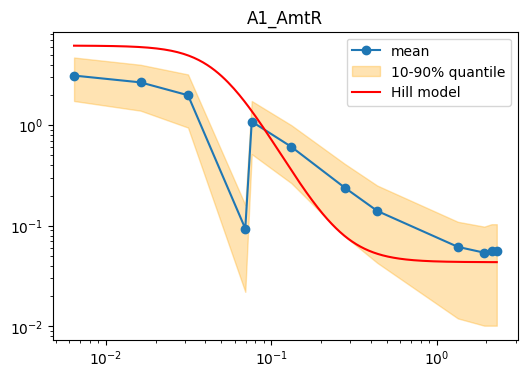

In [ ]:
from scipy.stats import rv_discrete

x_vals = []
means = []
q10 = []
q90 = []

for d in measurements:
    x = d['x']
    vals = np.array(d['bin'], dtype=float)
    probs = np.array(d['output'], dtype=float)
    
    probs = probs / probs.sum()
    
    dist = rv_discrete(values=(vals, probs))
    
    mean = dist.mean()
    q10_val = dist.ppf(0.1)
    q90_val = dist.ppf(0.9)
    
    x_vals.append(x)
    means.append(mean)
    q10.append(q10_val)
    q90.append(q90_val)


x_vals = np.array(x_vals)
means = np.array(means)
q10 = np.array(q10)
q90 = np.array(q90)

sort_idx = np.argsort(x_vals)

x_vals = x_vals[sort_idx]
means = means[sort_idx]
q10 = q10[sort_idx]
q90 = q90[sort_idx]


plt.figure(figsize=(6,4))

plt.plot(x_vals, means, marker='o', label='mean')

plt.fill_between(x_vals, q10, q90, color='orange', alpha=0.3, label='10-90% quantile')

plt.xscale('log')
plt.yscale('log')

x = np.linspace(x_vals[0], x_vals[-1], 1000)
plt.plot(x, inv(x), 'red', label = 'Hill model')
plt.title(gate_name)
plt.legend()

# Compiler for Inverter Chains
I defined "good" to mean that, at every interface, the upstream gate’s low-output distribution is below the follower’s low threshold and its high-output distribution is above the follower’s high threshold, each with probability >= 0.95. With the measured UCF data, no pair of NOR gates satisfies both conditions simultaneously, so for L > 1 the compiler reports that no solution was found.

In [ ]:
import re
import numpy as np

def quantile_from_hist(bins, probs, q):
    cdf = np.cumsum(probs)
    cdf /= cdf[-1] if cdf[-1] else 1.0
    return np.interp(q, cdf, bins)

def cdf_from_hist(bins, probs, x):
    cdf = np.cumsum(probs)
    cdf /= cdf[-1] if cdf[-1] else 1.0
    idx = np.searchsorted(bins, x, side='right') - 1
    if idx < 0:
        return 0.0
    if idx >= len(cdf):
        return 1.0
    return cdf[idx]

def hill_y(ymin, ymax, K, n, x):
    return ymin + (ymax - ymin) / (1.0 + (x / K)**n)

def hill_inv_x(ymin, ymax, K, n, y):
    span = ymax - ymin
    r = span / (y - ymin) - 1.0
    x_over_K = r**(1.0/n)
    return K * x_over_K

def thresholds_from_hill(ymin, ymax, K, n):
    y10 = ymin + 0.9*(ymax - ymin)   # high output level
    y90 = ymin + 0.1*(ymax - ymin)   # low output level
    IL = hill_inv_x(ymin, ymax, K, n, y10)  # low-input threshold
    IH = hill_inv_x(ymin, ymax, K, n, y90)  # high-input threshold
    return float(IL), float(IH)

class Gate:
    def __init__(self, name, params, cyt_tables):
        self.name = name
        self.ymin = float(params['ymin']); self.ymax = float(params['ymax'])
        self.K = float(params['K']); self.n = float(params['n'])
        self.IL, self.IH = thresholds_from_hill(self.ymin, self.ymax, self.K, self.n)
        # store cytometry tables as (x, bins, probs)
        self.tables = sorted(
            [(float(t['x']), np.array(t['bin'], float), np.array(t['output'], float)) for t in cyt_tables],
            key=lambda z: z[0]
        )

    def get_dist(self, x):
        if not self.tables:
            y = hill_y(self.ymin, self.ymax, self.K, self.n, x)
            bins = np.array([0.9*y, y, 1.1*y])
            probs = np.array([0.05, 0.9, 0.05])
            return bins, probs
        lx = np.log10(max(x, 1e-12))
        best = min(self.tables, key=lambda t: abs(np.log10(max(t[0], 1e-12)) - lx))
        return best[1], best[2]

def compile_inv_chain(L, gates, x0=1e-4, x1=1e1, prob_req=0.95):
    chosen = []
    interfaces = []
    cur_x0, cur_x1 = x0, x1

    for i in range(L):
        best = None
        for g in gates:
            bins0, p0 = g.get_dist(cur_x0)
            bins1, p1 = g.get_dist(cur_x1)
            if i == L - 1:
                score = abs(g.n) * np.log(max(g.ymax/g.ymin, 1.0001))
                candidate = (score, g, None)
            else:
                best_follow = None
                for h in gates:
                    IL, IH = h.IL, h.IH
                    P0 = cdf_from_hist(bins0, p0, IL)
                    P1 = 1.0 - cdf_from_hist(bins1, p1, IH)
                    if P0 >= prob_req and P1 >= prob_req:
                        q95_0 = quantile_from_hist(bins0, p0, 0.95)
                        q05_1 = quantile_from_hist(bins1, p1, 0.05)
                        m0 = np.log(IL) - np.log(max(q95_0, 1e-12))
                        m1 = np.log(max(q05_1, 1e-12)) - np.log(IH)
                        margin = min(m0, m1)
                        if (best_follow is None) or (margin > best_follow[0]):
                            best_follow = (margin, h, (P0, P1, m0, m1))
                if best_follow is None:
                    continue
                candidate = (best_follow[0], g, best_follow)

            if (best is None) or (candidate[0] > best[0]):
                best = candidate

        if best is None:
            return None, interfaces

        _, g, follow = best
        chosen.append(g)

        bins0, p0 = g.get_dist(cur_x0)
        bins1, p1 = g.get_dist(cur_x1)
        q95_0 = quantile_from_hist(bins0, p0, 0.95)
        q05_1 = quantile_from_hist(bins1, p1, 0.05)
        interfaces.append({
            "stage": i+1,
            "gate": g.name,
            "x_in_low": cur_x0, "x_in_high": cur_x1,
            "y_low_q95": q95_0, "y_high_q05": q05_1,
            "follower_checked": follow[1].name if (follow and i < L-1) else None,
            "P0<=IL": follow[2][0] if (follow and i < L-1) else None,
            "P1>=IH": follow[2][1] if (follow and i < L-1) else None,
            "m0_log": follow[2][2] if (follow and i < L-1) else None,
            "m1_log": follow[2][3] if (follow and i < L-1) else None,
        })

        cur_x0, cur_x1 = q95_0, q05_1

    return chosen, interfaces

gates_raw = [g for g in ucf_data if g.get('collection') == 'gates' and g.get('gate_type','').lower() == 'nor']
models = {m['name']: m for m in ucf_data if m.get('collection') == 'models'}
functions = {f['name']: f for f in ucf_data if f.get('collection') == 'functions'}

gates = []
for g in gates_raw:
    m = models.get(g['model'])
    if not m:
        continue
    params = {p['name']: p['value'] for p in m['parameters']}
    cyt_name = g['name'] + '_cytometry'
    cyt = functions.get(cyt_name, {"table": []})
    gates.append(Gate(g['name'], params, cyt.get('table', [])))

print(f"Parsed {len(gates)} NOR gates from in-memory UCF data.")

# try compiling a chain
L = 1
chosen, report = compile_inv_chain(L, gates)

if chosen is None:
    print(f"\nNo solution found for L={L}.")
else:
    print(f"\nChain for L={L}:")
    for i, g in enumerate(chosen, 1):
        print(f"  {i}. {g.name}")
    print("\nInterface report (per stage):")
    for r in report:
        print(f"Stage {r['stage']} — {r['gate']}: "
              f"x_in_low={r['x_in_low']:.3e}, x_in_high={r['x_in_high']:.3e}, "
              f"y_low_q95={r['y_low_q95']:.3e}, y_high_q05={r['y_high_q05']:.3e}, "
              f"follower={r['follower_checked']}, "
              f"P0<=IL={r['P0<=IL']}, P1>=IH={r['P1>=IH']}, "
              f"m0_log={r['m0_log']}, m1_log={r['m1_log']}")

Parsed 18 NOR gates from in-memory UCF data.

Chain for L=1:
  1. P2_PhlF

Interface report (per stage):
Stage 1 — P2_PhlF: x_in_low=1.000e-04, x_in_high=1.000e+01, y_low_q95=1.505e+01, y_high_q05=2.674e-03, follower=None, P0<=IL=None, P1>=IH=None, m0_log=None, m1_log=None


## Simulating Distributions
Here, I defined a "good" inverter chain to refer to a single inverter, meaning that it maintains a clear logical inversion and keeps the output well-defined.
And a "bad" inverter to refer to two inverters connected in series, meaning that the signal is brought back to its original polarity and that the output distribution becomes broader, and logical levels start to overlap.


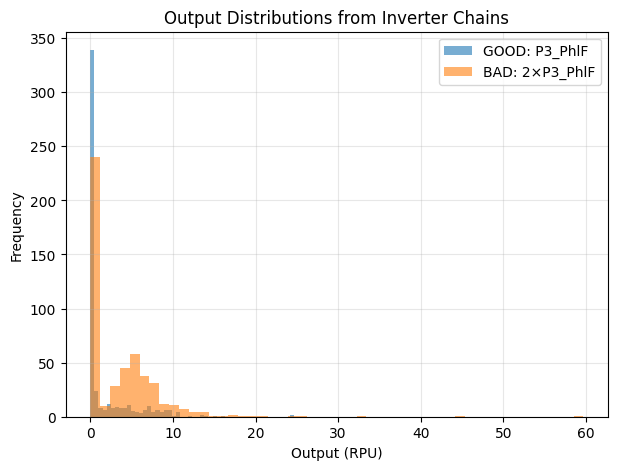

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sample_from_hist(bins, probs, n_samples=1):
    """Draw n_samples from a discrete histogram."""
    probs = np.array(probs, dtype=float)
    if probs.sum() == 0:
        probs = np.ones_like(bins, dtype=float)
    probs /= probs.sum()
    return np.random.choice(bins, size=n_samples, p=probs)

def propagate_distribution(circuit, input_samples):
    """
    Simulate propagation of signal distributions through a linear inverter chain.

    circuit: list of Gate objects (single-input NORs)
    input_samples: array of float inputs (RPUs)
    returns: array of simulated output samples (RPUs)
    """
    x = np.array(input_samples, dtype=float)
    for gate in circuit:
        new_x = []
        for xi in x:
            bins, probs = gate.get_dist(xi)
            y = sample_from_hist(bins, probs, n_samples=1)[0]
            new_x.append(y)
        x = np.array(new_x)
    return x

good_gate = gates[0]
good_circuit = [good_gate]
bad_circuit = [good_gate, good_gate]

input_samples = np.logspace(-2, 2, 500)
np.random.shuffle(input_samples)

out_good = propagate_distribution(good_circuit, input_samples)
out_bad = propagate_distribution(bad_circuit, input_samples)

plt.figure(figsize=(7,5))
plt.hist(out_good, bins=50, alpha=0.6, label=f"GOOD: {good_circuit[0].name}")
plt.hist(out_bad,  bins=50, alpha=0.6, label=f"BAD: 2×{good_circuit[0].name}")
plt.xlabel("Output (RPU)")
plt.ylabel("Frequency")
plt.title("Output Distributions from Inverter Chains")
plt.legend()
plt.grid(alpha=0.3)
plt.show()